# 01 - Data Prep and EDA

Objetivo:
- crear splits reproducibles
- validar distribución por clase
- inspeccionar ejemplos

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from real_estate_ml.config import load_config
from real_estate_ml.constants import CLASSES
from real_estate_ml.data.prepare_splits import prepare_splits

cfg = load_config(ROOT / "configs" / "base_config.yaml")
cfg

{'project_name': 'real-estate-classifier',
 'entity': '202529987-universidad-pontificia-comillas',
 'data': {'data_dir': 'data/processed',
  'raw_training_dir': 'data/raw/dataset/training',
  'raw_validation_dir': 'data/raw/dataset/validation',
  'num_classes': 15,
  'image_size': 224,
  'batch_size': 32,
  'num_workers': 4,
  'train_split': 0.7,
  'val_split': 0.15,
  'test_split': 0.15},
 'model': {'backbone': 'efficientnet_b0',
  'pretrained': True,
  'dropout': 0.3,
  'freeze_backbone': False},
 'training': {'epochs': 30,
  'learning_rate': '1e-4',
  'weight_decay': '1e-4',
  'seed': 42,
  'save_dir': 'artifacts',
  'scheduler': 'cosine',
  'early_stopping_patience': 5},
 'hardware': {'device': 'cuda', 'mixed_precision': True}}

In [2]:
prepare_splits(
    raw_training_dir=ROOT / cfg["data"]["raw_training_dir"],
    raw_validation_dir=ROOT / cfg["data"]["raw_validation_dir"],
    output_dir=ROOT / cfg["data"]["data_dir"],
    train_split=cfg["data"]["train_split"],
    val_split=cfg["data"]["val_split"],
    test_split=cfg["data"]["test_split"],
    seed=cfg["training"]["seed"],
)

Bedroom: total=216, train=151, val=32, test=33
Coast: total=360, train=251, val=54, test=55
Forest: total=328, train=229, val=49, test=50
Highway: total=260, train=182, val=39, test=39
Industrial: total=311, train=217, val=46, test=48
Inside city: total=308, train=215, val=46, test=47
Kitchen: total=210, train=147, val=31, test=32
Living room: total=289, train=202, val=43, test=44
Mountain: total=374, train=261, val=56, test=57
Office: total=215, train=150, val=32, test=33
Open country: total=410, train=287, val=61, test=62
Store: total=315, train=220, val=47, test=48
Street: total=292, train=204, val=43, test=45
Suburb: total=241, train=168, val=36, test=37
Tall building: total=356, train=249, val=53, test=54


In [3]:
def count_images(split_name: str):
    rows = []
    split_dir = ROOT / cfg["data"]["data_dir"] / split_name
    for class_name in CLASSES:
        class_dir = split_dir / class_name
        count = len(list(class_dir.glob("*.jpg"))) + len(list(class_dir.glob("*.jpeg"))) + len(list(class_dir.glob("*.png")))
        rows.append({"split": split_name, "class": class_name, "count": count})
    return pd.DataFrame(rows)

df = pd.concat([count_images("train"), count_images("val"), count_images("test")], ignore_index=True)
df.head()

,split,class,count
0,train,Bedroom,151
1,train,Coast,251
2,train,Forest,229
3,train,Highway,182
4,train,Industrial,217


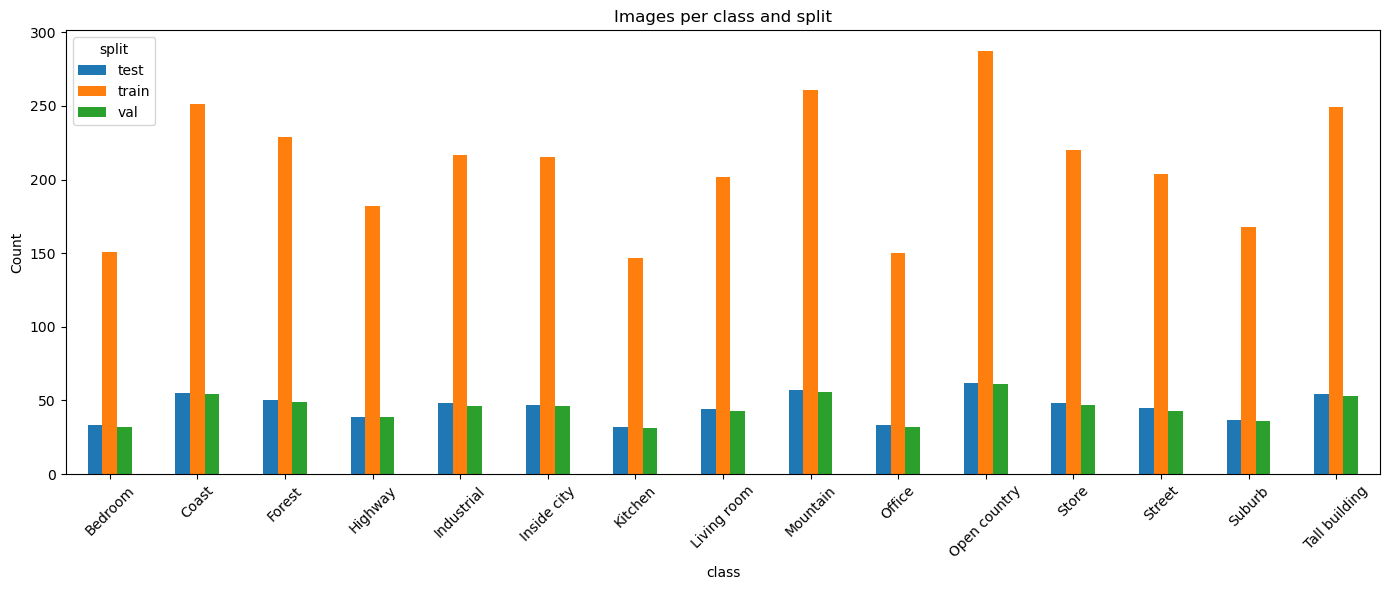

split,test,train,val
class,,,
Bedroom,33,151,32
Coast,55,251,54
Forest,50,229,49
Highway,39,182,39
Industrial,48,217,46
Inside city,47,215,46
Kitchen,32,147,31
Living room,44,202,43
Mountain,57,261,56


In [4]:
pivot = df.pivot(index="class", columns="split", values="count")
pivot.plot(kind="bar", figsize=(14, 6), rot=45)
plt.title("Images per class and split")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

pivot